In [1]:
# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import grid_simulation

import numpy as np

from torch import multiprocessing

%reload_ext autoreload
%autoreload 2

from cuda_square_simulation import SquareSimulation

# Utils
torch.manual_seed(0)
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

In [8]:
def clever_single_action(env, action_batch, obs_indices):
    if action_batch is None:
        return None
    
    # By default, random actions
    # Pop 0 is random
    # Pop 1 is semi-random
    # Pop 2 is random
    actions = env.configurable_actions_grid(None, None, 'random')
    
    batch_idx, x_idx, y_idx = obs_indices.T

    # Now assign:
    # 0: move to clever
    actions[batch_idx, x_idx, y_idx] = action_batch.float()
    
    return actions

# Unstable REINFORCE

In [9]:
device = (
    torch.device(0)
    if torch.cuda.is_available()
    else torch.device("cpu")
)

print(f"Using device: {device}")

lr = 1e-3
max_grad_norm = 1.0

Using device: cuda:0


In [10]:
# Define the observation shape as returned by get_deep_observations.
# For example, if your simulation returns patches of shape (C, obs_size, obs_size)
# and C = number_of_populations (say 3) and obs_size is 5:
obs_shape = (3, 5, 5)

# Simple policy network for a discrete action space (0 to 16):
class PolicyNet(nn.Module):
    def __init__(self, obs_shape, num_actions=17):        
        super().__init__()
        
        self.saved_log_probs = []
        self.rewards = []
        self.exploration_importance = 100
        self.observation_indices = []
        
        self.all_rewards = []
        self.all_losses = []
        self.action_counts = [0] * num_actions
        
        C, H, W = obs_shape
        # Flatten the observation
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(C * H * W, 100)
        self.dropout = nn.Dropout(p=0.1)
        self.fc2 = nn.Linear(100, num_actions)
        #self.fc3 = nn.Linear(100, num_actions)
        
    def forward(self, x):
        # x shape: (batch, C, H, W)
        x = x.view(x.size(0), -1)  # Flatten the input
        x = torch.relu(self.fc1(x))
        
        x = self.dropout(x)  # Apply dropout
        
        #x = torch.relu(self.fc2(x))
        logits = self.fc2(x)
        
        probs = F.softmax(logits, dim=-1)  # Convert logits to probabilities

        return probs

# Create the policy and the corresponding optimizer:
policy_net = PolicyNet(obs_shape).to(device)
optimizer = optim.Adam(policy_net.parameters(), lr)

In [11]:
nb_batches = 50
rows, cols = 20, 20
populations = {
    "red": {"p": 0.05, "mean_v": 10.0, "std_v": 0.2},
    "blue": {"p": 0.05, "mean_v": 10.0, "std_v": 0.2},
    "green": {"p": 0.05, "mean_v": 10.0, "std_v": 0.2},
}

gamma = 0.98

clever_pop_id = 0  # Clever population ID

simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols, populations=populations, device=device)
simulation.reset()

In [12]:
from collections import defaultdict
from itertools import accumulate

def select_action(observations):
    if observations.size(0) == 0:
        return None
    
    # Run the policy network on the observations
    probs = policy_net(observations)
    
    m = Categorical(probs)
    
    action = m.sample()  # Size: (batch_size,)
    
    unique, counts = torch.unique(action, return_counts=True)
    for u, c in zip(unique.tolist(), counts.tolist()):
        policy_net.action_counts[u] += c / 10000
    
    policy_net.saved_log_probs.append(m.log_prob(action))

    return action

from collections import defaultdict

def finish_episode(policy_net, optimizer, gamma=0.99, max_grad_norm=1.0):
    if not policy_net.saved_log_probs:
        return

    device = policy_net.saved_log_probs[0].device
    T      = len(policy_net.rewards)

    # ---------- 2.1  gather all agent‑ids once, build mapping ----------
    # cat →  (∑_t n_t, 3)
    flat_ids      = torch.cat(policy_net.observation_indices, dim=0)
    # unique over rows gives:  unique_ids … (N,3),  inverse_map … (∑_t n_t,)
    unique_ids, inverse_map = torch.unique(flat_ids,
                                           return_inverse=True,
                                           dim=0)
    N_agents = unique_ids.size(0)

    # how many agents appear at each timestep?
    lens   = torch.tensor([ids.size(0) for ids in policy_net.observation_indices],
                          device=device)                                # (T,)
    # cumulative lengths let us slice inverse_map without Python loops
    # ptr[t] = start index for timestep t inside inverse_map
    ptr = torch.cat((lens.new_zeros(1), lens.cumsum(0)), dim=0)         # (T+1,)

    running_return = torch.zeros(N_agents, device=device)
    returns        = [None] * T            # will fill from back to front

    # ---------- 2.2  backwards pass over timesteps (no inner loop) ----
    for t in range(T - 1, -1, -1):
        idx_slice   = inverse_map[ptr[t]:ptr[t+1]]      # (n_t,)  long / int64
        step_return = policy_net.rewards[t].to(torch.float32)

        # vectorised Bellman update:
        #   R_a ← r_t(a) + γ·R_a     ∀ agents present at this timestep
        running_return.index_put_((idx_slice,),
                                  step_return + gamma * running_return[idx_slice],
                                  accumulate=False)

        returns[t] = running_return[idx_slice]           # (n_t,)

    # ---------- 2.3  flatten, standardise, loss -----------------------
    flat_returns   = torch.cat(returns,        dim=0)             # matches order
    flat_log_probs = torch.cat(policy_net.saved_log_probs, dim=0)

    flat_returns = (flat_returns - flat_returns.mean()) / (flat_returns.std() + 1e-8)
    policy_loss  = -(flat_log_probs * flat_returns).sum()

    # optional entropy bonus
    entropy = (-flat_log_probs).mean()
    policy_loss -= policy_net.exploration_importance * entropy
    policy_net.exploration_importance *= 0.95

    # ---------- 2.4  optimise ----------------------------------------
    optimizer.zero_grad(set_to_none=True)
    policy_loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_grad_norm)
    optimizer.step()

    # ---------- 2.5  bookkeeping -------------------------------------
    policy_net.all_losses.append(policy_loss.item())
    episode_return = sum(r.sum().item() for r in policy_net.rewards)
    policy_net.all_rewards.append(episode_return)

    policy_net.rewards.clear()
    policy_net.saved_log_probs.clear()
    policy_net.observation_indices.clear()


In [13]:
learn_steps = 10
nb_epochs = 50


for i_episode in tqdm(range(nb_epochs)):
    simulation.reset()
    ep_reward = 0
    
    # print(f"Episode {i_episode} - Time 0.")
    # plt.figure(dpi=20)
    # grid_simulation.run_visual_simulation_grid(simulation)
    
    for t in tqdm(range(750), leave=False):
        with torch.no_grad():
            observations, obs_indices = simulation.get_deep_observations(clever_pop_id)
        
        action = select_action(observations)

        with torch.no_grad():
            all_actions_grid = clever_single_action(simulation, action, obs_indices) 
            
            rewards, done, info = simulation.step(all_actions_grid, obs_indices)
            
            # print(f"Episode {i_episode} - Time {t} - Reward: {rewards[clever_pop_id]:.4f} - Done: {done} - Action: {action is None}")
            # print("Number of clever pop:", (simulation.grid[:, clever_pop_id] > simulation.EPS).sum().item())
        
        # clever_pop_rewards = rewards
        # clever_pop_rewards = clever_pop_rewards / nb_batches
        clever_pop_rewards = rewards
        
        policy_net.rewards.append(clever_pop_rewards)
        policy_net.observation_indices.append(obs_indices.detach().cpu())
        ep_reward += clever_pop_rewards.mean().item()
        
        if t % learn_steps == 0 and t > 0:
            # Update the policy every 50 steps           
            finish_episode(policy_net, optimizer)
            
    print(f"Episode {i_episode} - Time {t} - Avg reward: {ep_reward:.4f} - Loss: {policy_net.all_losses[-1]:.2f} - Action counts: {100 *np.array(policy_net.action_counts) / np.sum(policy_net.action_counts)}")
    # plt.figure(dpi=20)
    # grid_simulation.run_visual_simulation_grid(simulation)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/750 [00:00<?, ?it/s]

TypeError: SquareSimulation.step() takes from 1 to 2 positional arguments but 3 were given

In [ ]:
# Save the model
torch.save(policy_net.state_dict(), "policy_net.pth")

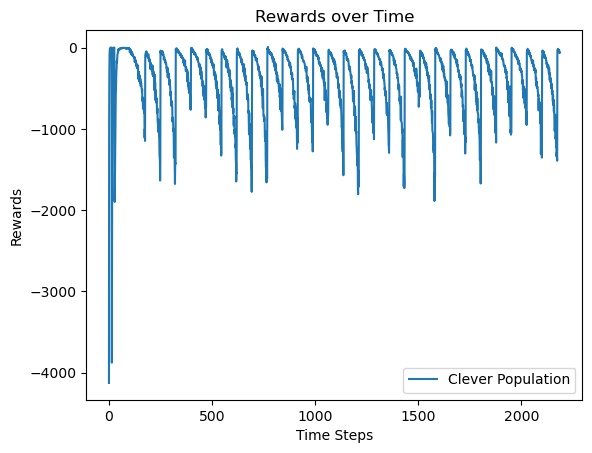

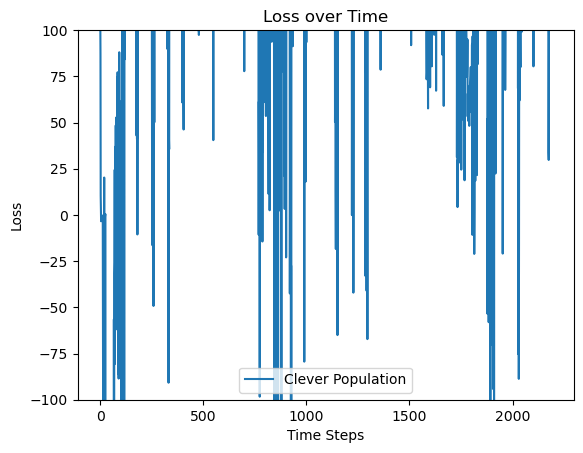

In [ ]:
# Plot the rewards
plt.plot(policy_net.all_rewards, label="Clever Population")
plt.xlabel("Time Steps")
plt.ylabel("Rewards")
plt.title("Rewards over Time")
plt.legend()
plt.savefig("rewards.png")
plt.show()

plt.plot(policy_net.all_losses, label="Clever Population")
plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.title("Loss over Time")
plt.ylim(-100, 100)
plt.legend()

In [43]:
# Store model
torch.save(policy_net.state_dict(), "policy_net.pth")

# Visualize

<Figure size 128x96 with 0 Axes>

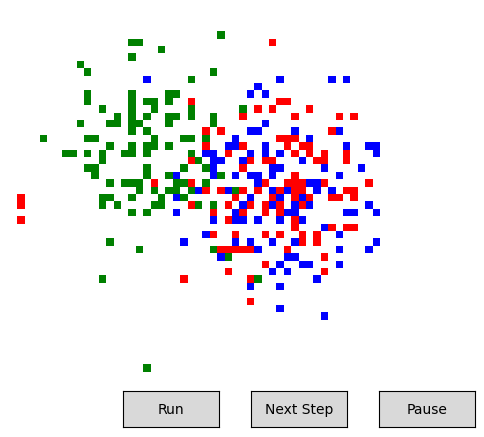

<Figure size 128x96 with 0 Axes>

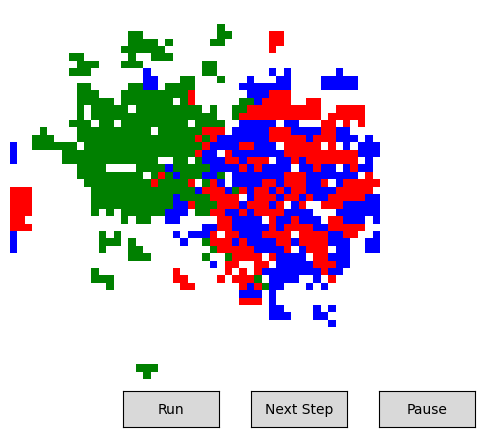

<Figure size 128x96 with 0 Axes>

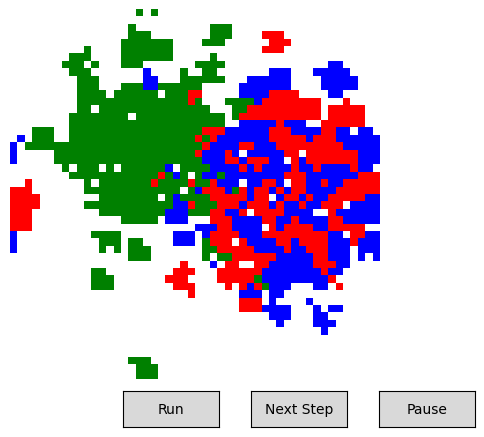

<Figure size 128x96 with 0 Axes>

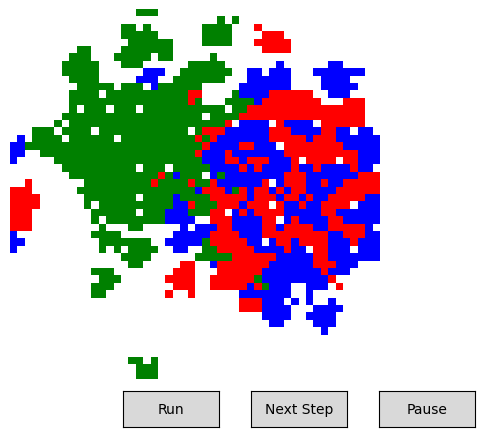

<Figure size 128x96 with 0 Axes>

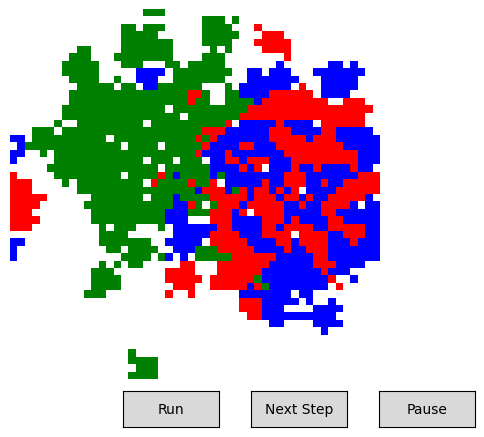

<Figure size 128x96 with 0 Axes>

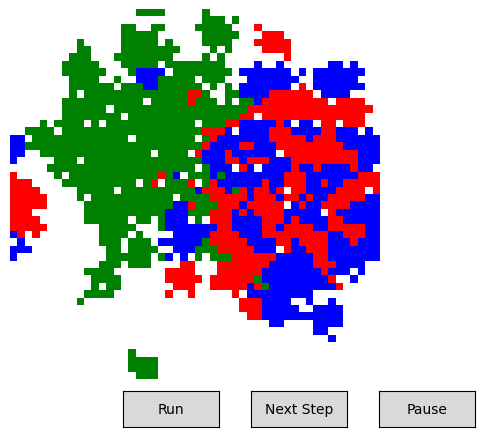

<Figure size 128x96 with 0 Axes>

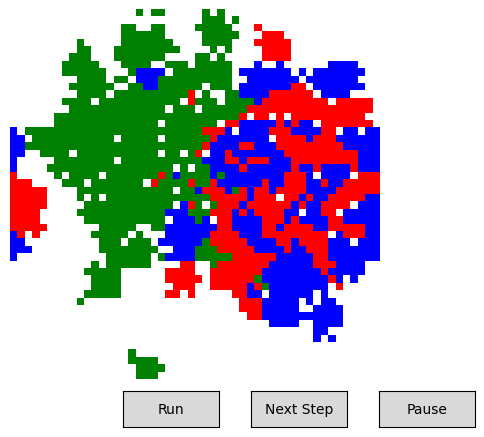

<Figure size 128x96 with 0 Axes>

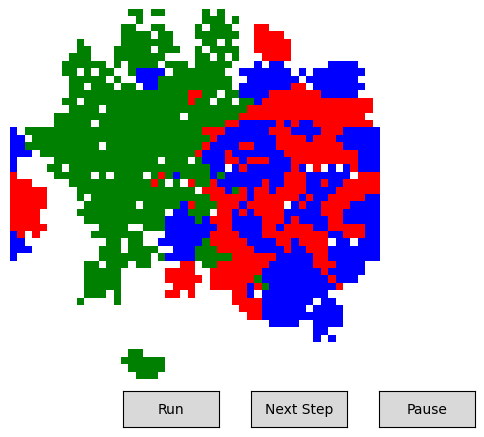

<Figure size 128x96 with 0 Axes>

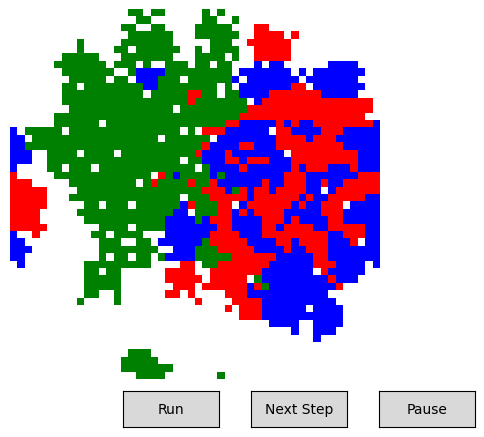

<Figure size 128x96 with 0 Axes>

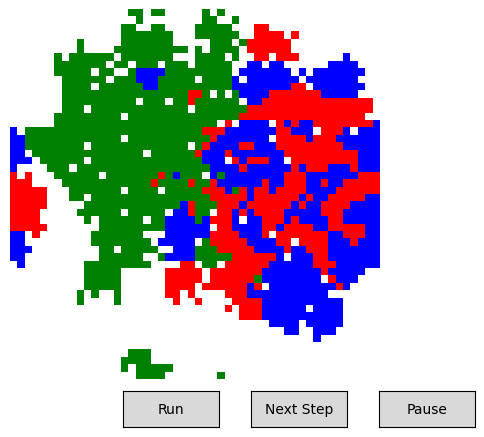

<Figure size 128x96 with 0 Axes>

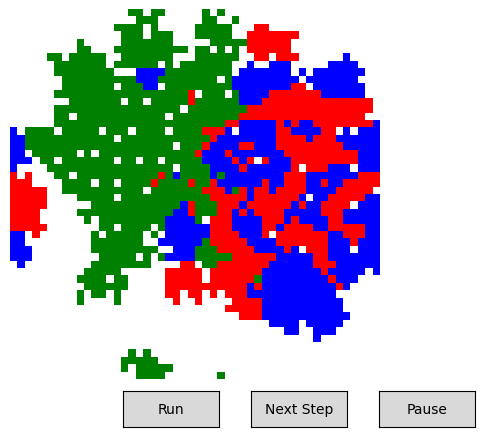

<Figure size 128x96 with 0 Axes>

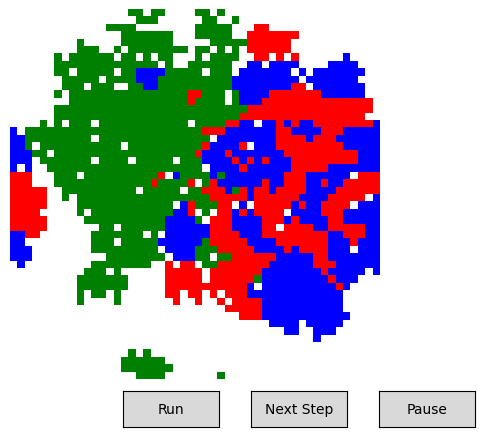

<Figure size 128x96 with 0 Axes>

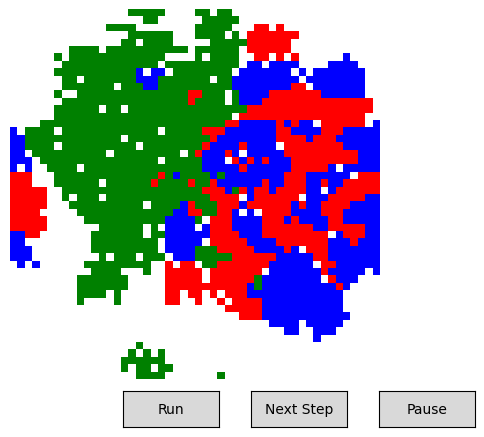

<Figure size 128x96 with 0 Axes>

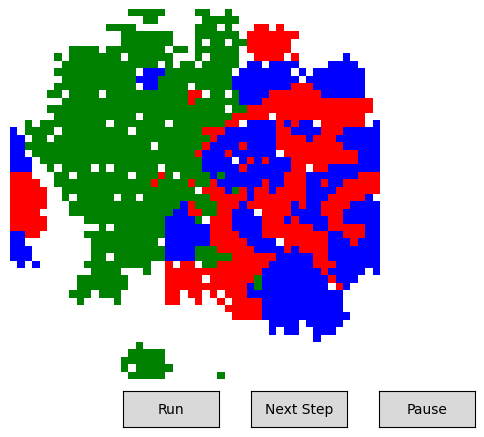

<Figure size 128x96 with 0 Axes>

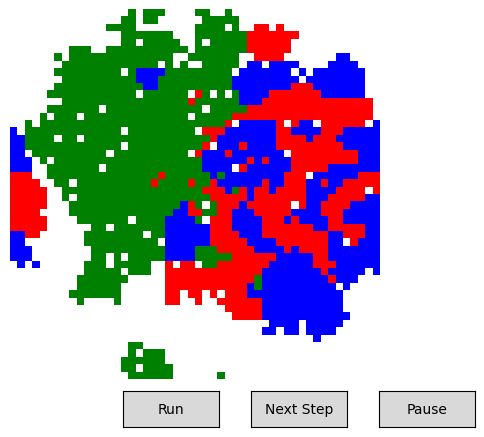

<Figure size 128x96 with 0 Axes>

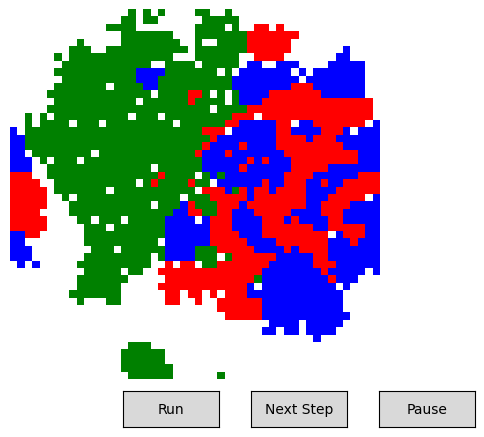

<Figure size 128x96 with 0 Axes>

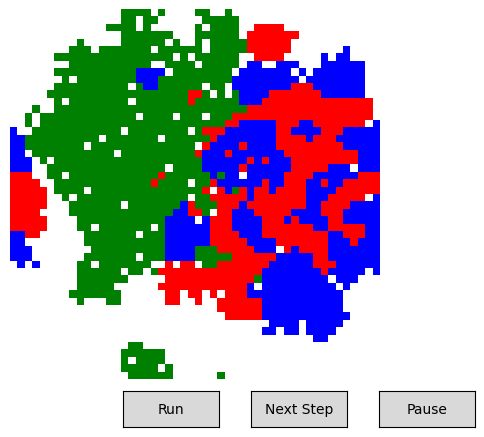

<Figure size 128x96 with 0 Axes>

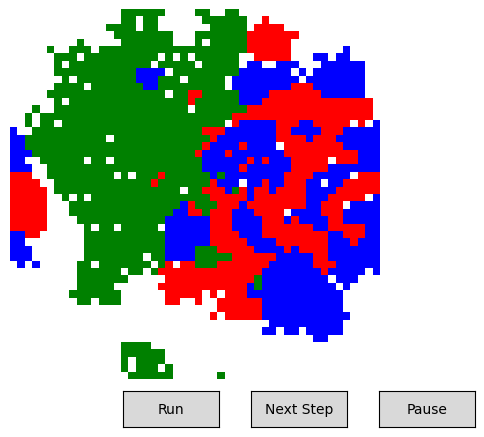

<Figure size 128x96 with 0 Axes>

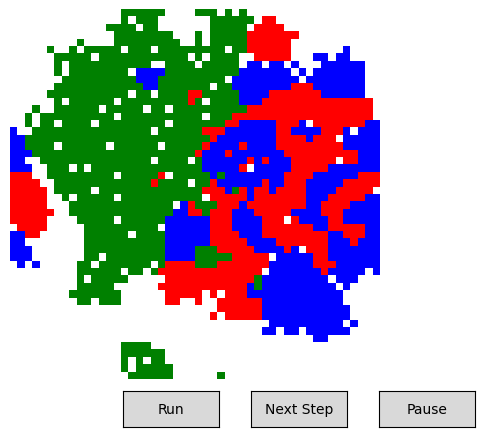

<Figure size 128x96 with 0 Axes>

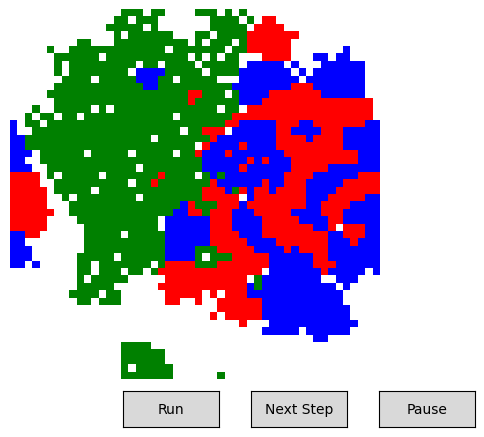

<Figure size 128x96 with 0 Axes>

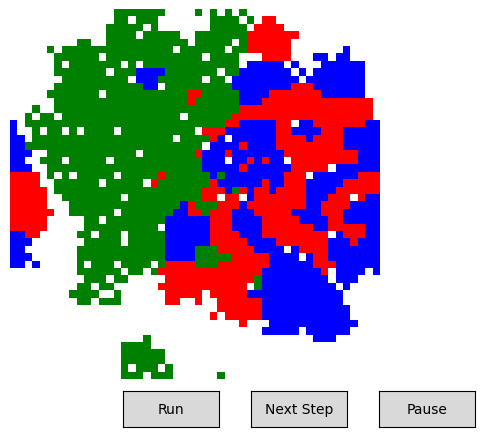

<Figure size 128x96 with 0 Axes>

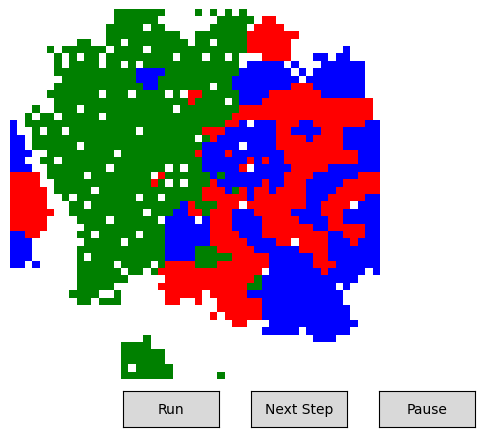

<Figure size 128x96 with 0 Axes>

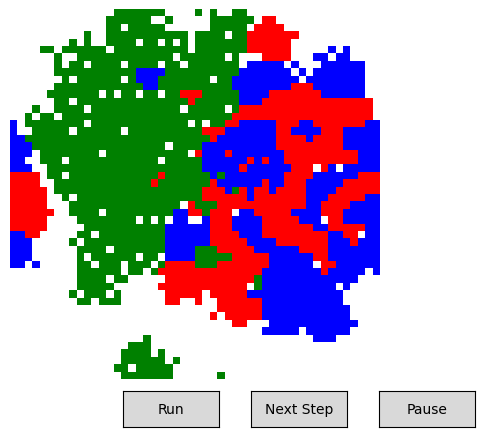

<Figure size 128x96 with 0 Axes>

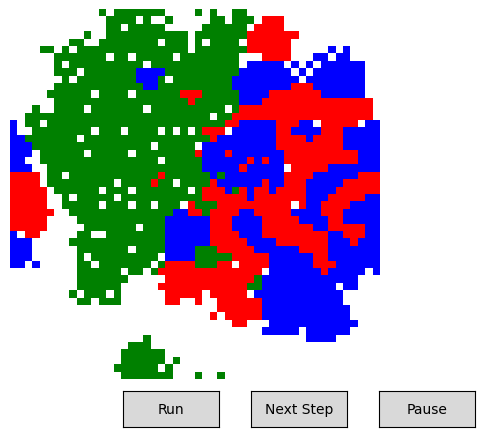

<Figure size 128x96 with 0 Axes>

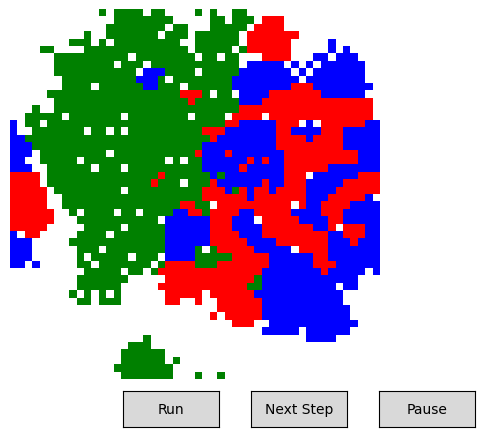

<Figure size 128x96 with 0 Axes>

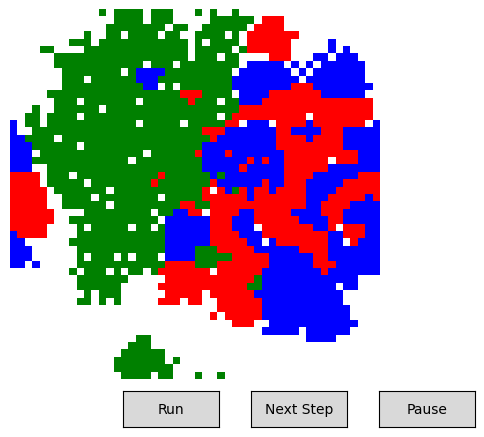

<Figure size 128x96 with 0 Axes>

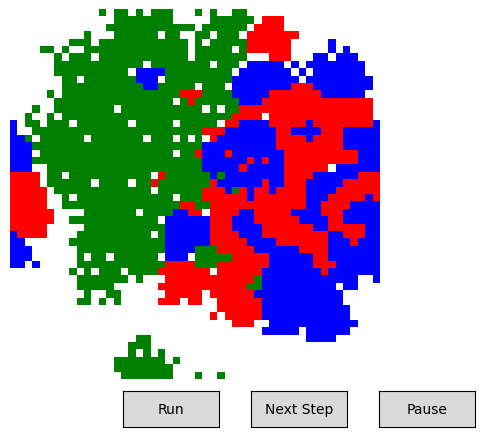

<Figure size 128x96 with 0 Axes>

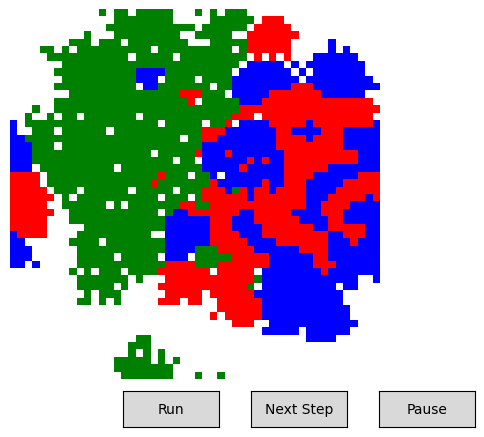

<Figure size 128x96 with 0 Axes>

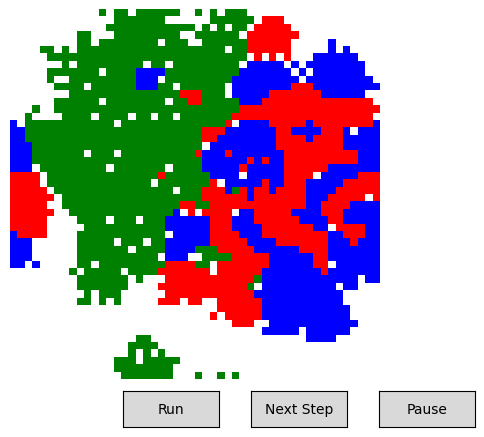

<Figure size 128x96 with 0 Axes>

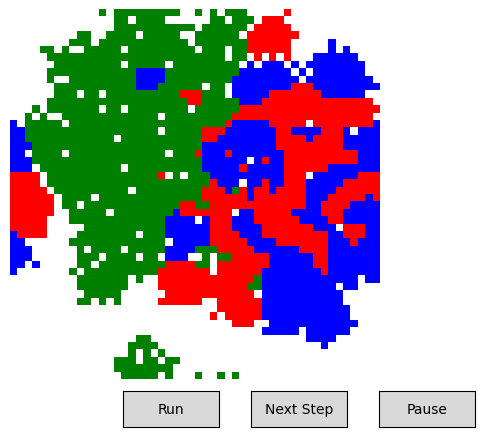

<Figure size 128x96 with 0 Axes>

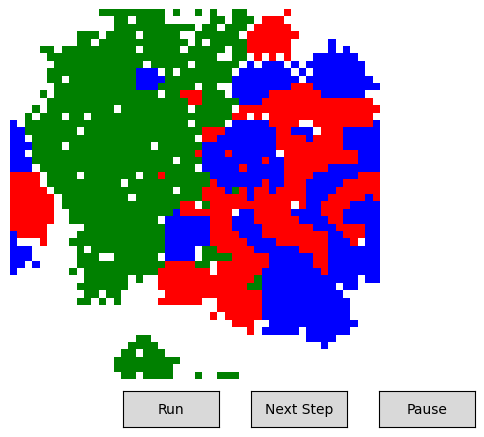

<Figure size 128x96 with 0 Axes>

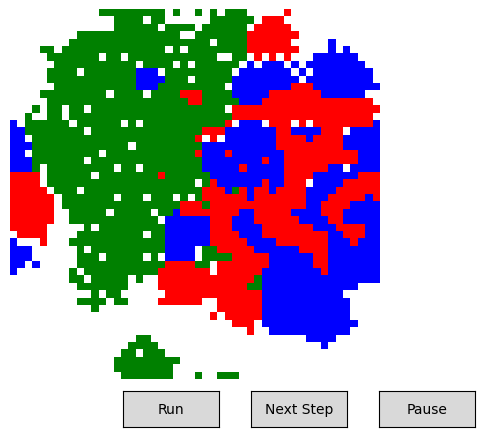

<Figure size 128x96 with 0 Axes>

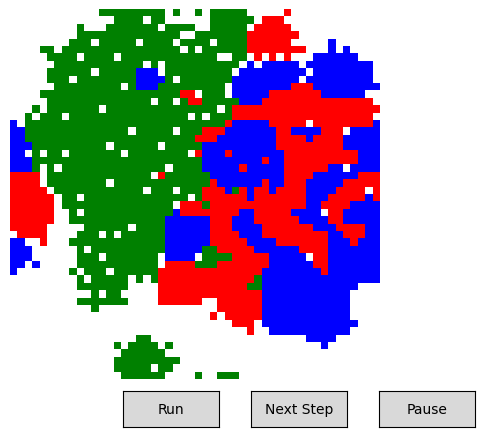

<Figure size 128x96 with 0 Axes>

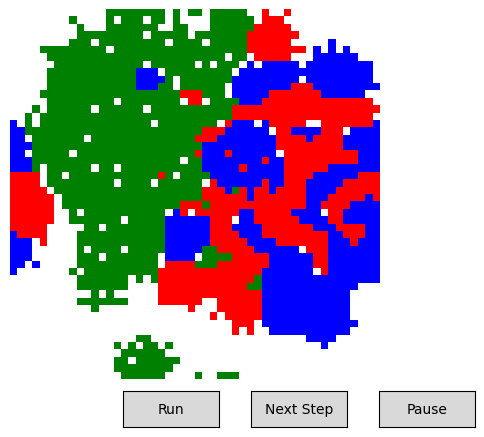

<Figure size 128x96 with 0 Axes>

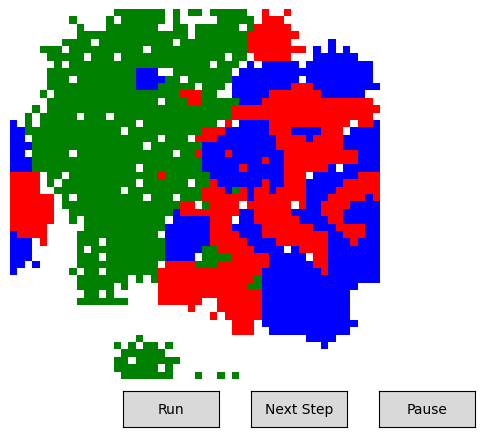

<Figure size 128x96 with 0 Axes>

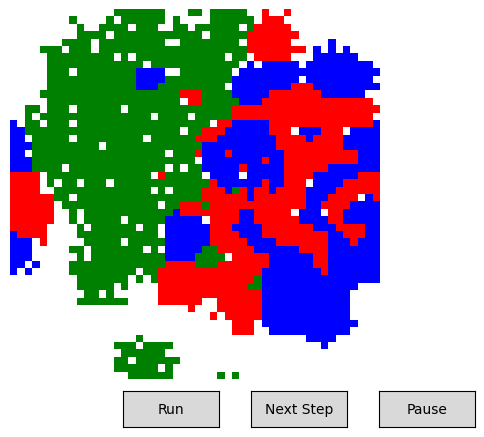

<Figure size 128x96 with 0 Axes>

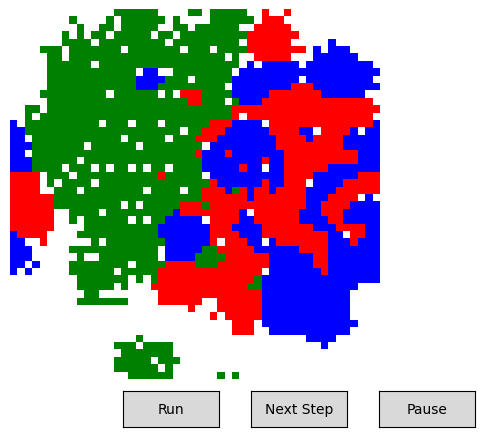

<Figure size 128x96 with 0 Axes>

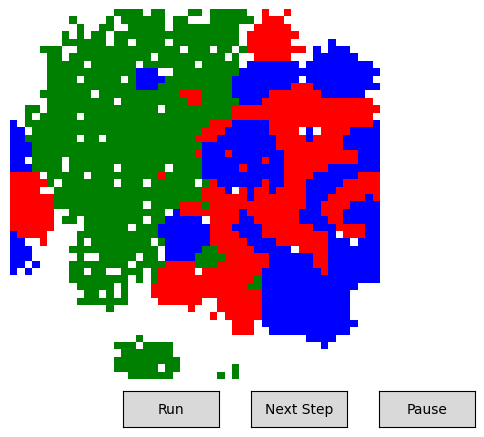

<Figure size 128x96 with 0 Axes>

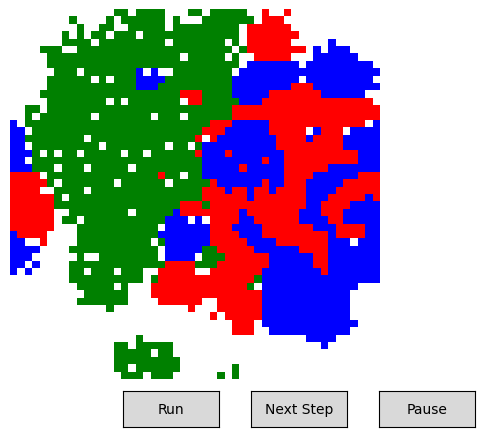

<Figure size 128x96 with 0 Axes>

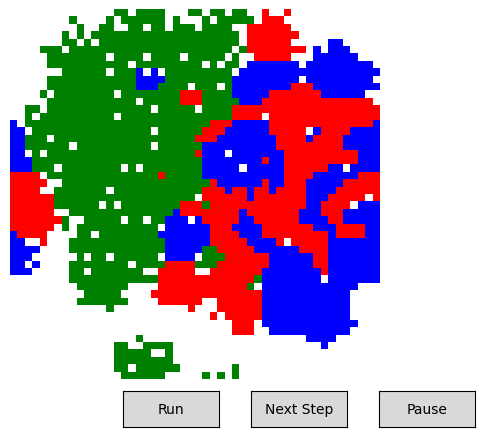

<Figure size 128x96 with 0 Axes>

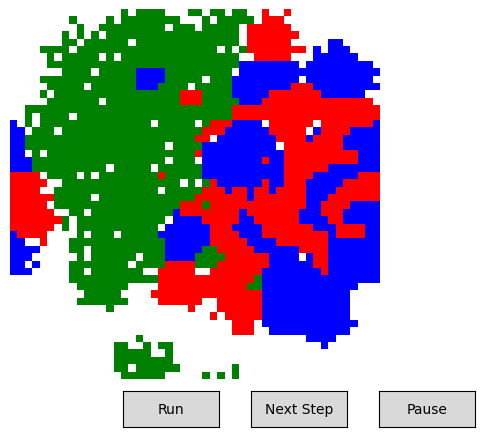

<Figure size 128x96 with 0 Axes>

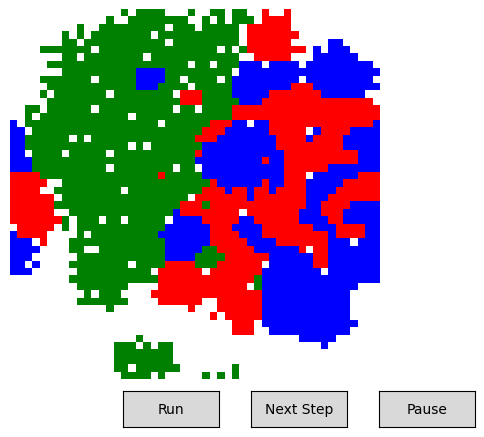

<Figure size 128x96 with 0 Axes>

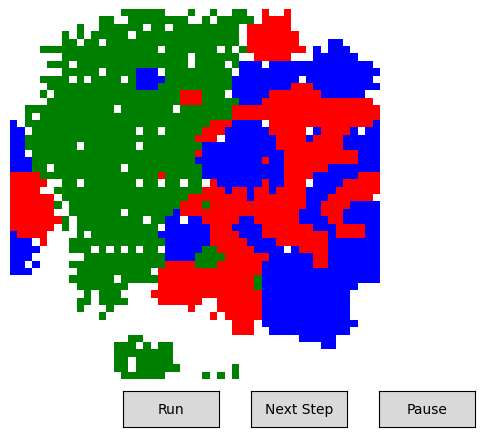

<Figure size 128x96 with 0 Axes>

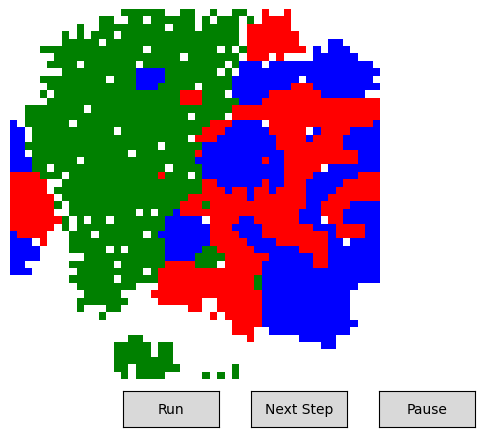

<Figure size 128x96 with 0 Axes>

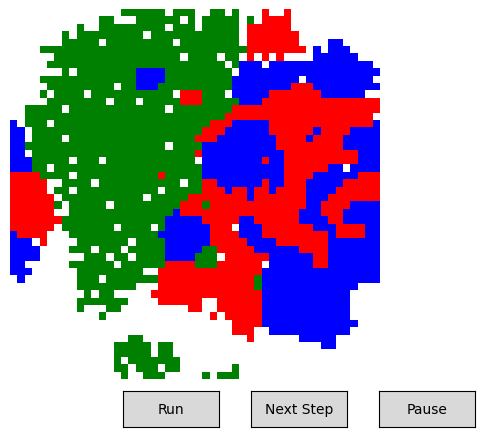

<Figure size 128x96 with 0 Axes>

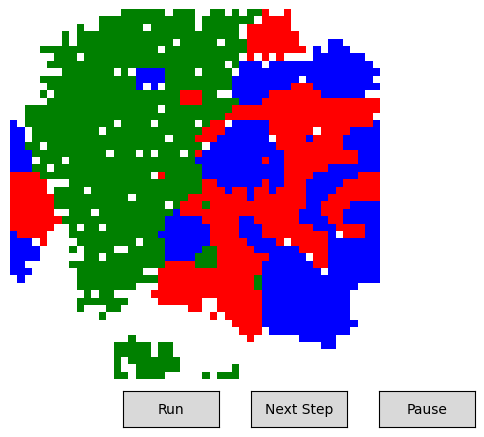

<Figure size 128x96 with 0 Axes>

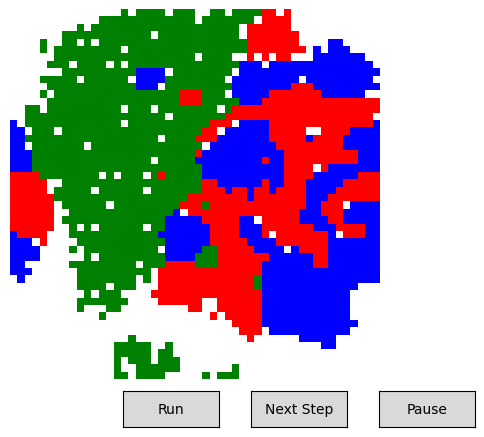

<Figure size 128x96 with 0 Axes>

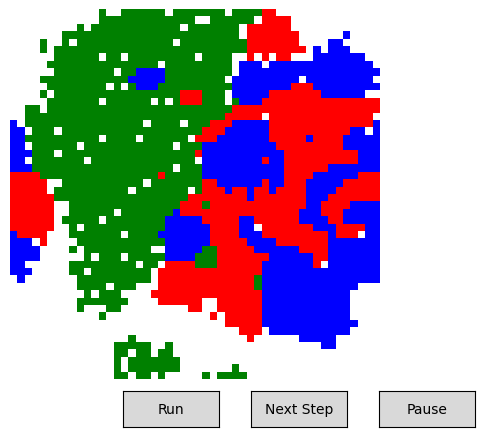

<Figure size 128x96 with 0 Axes>

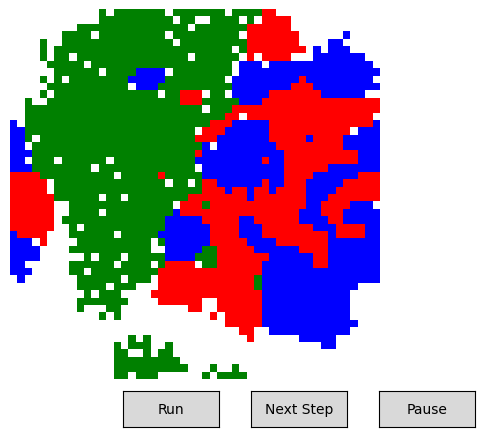

<Figure size 128x96 with 0 Axes>

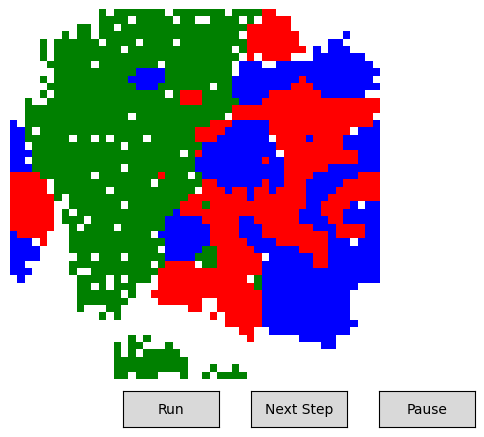

<Figure size 128x96 with 0 Axes>

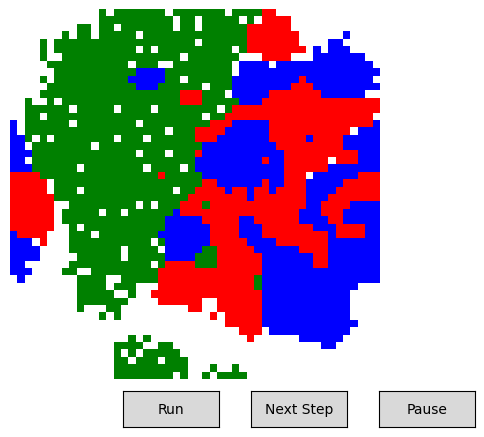

<Figure size 128x96 with 0 Axes>

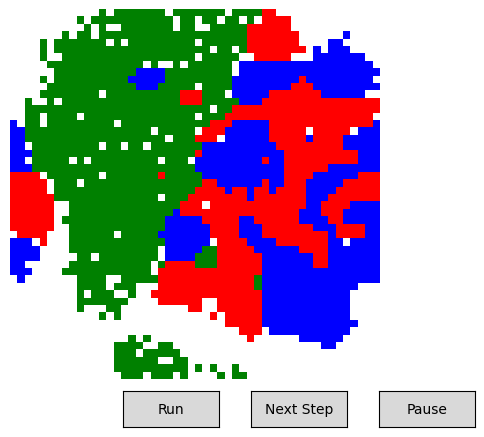

<Figure size 128x96 with 0 Axes>

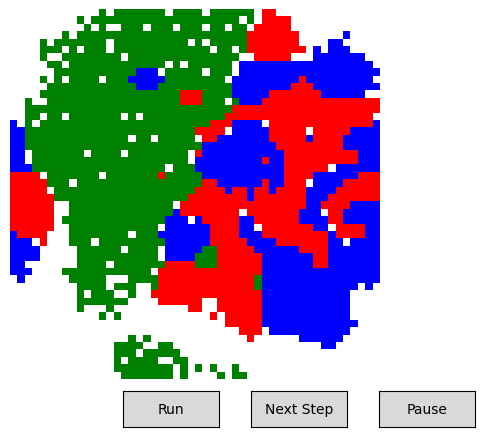

<Figure size 128x96 with 0 Axes>

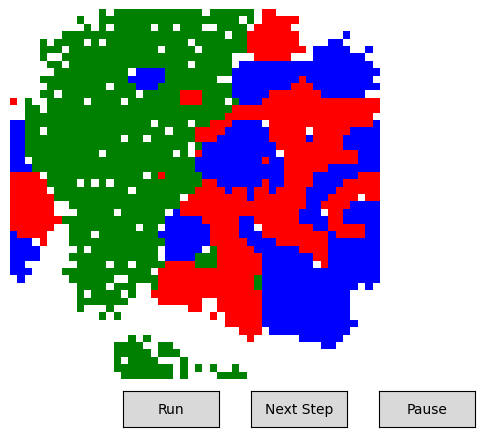

<Figure size 128x96 with 0 Axes>

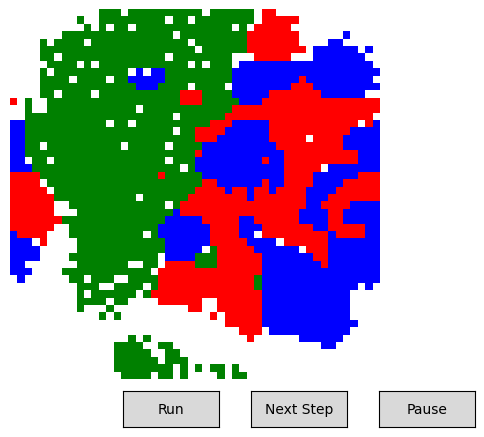

<Figure size 128x96 with 0 Axes>

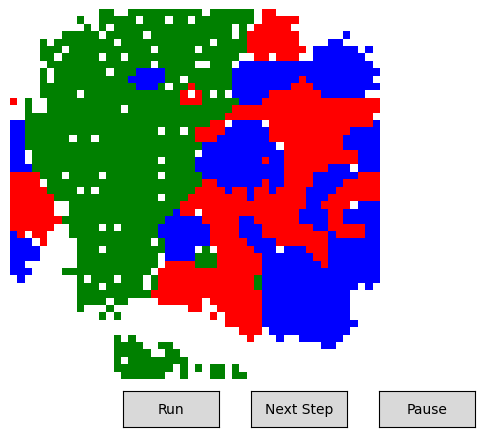

<Figure size 128x96 with 0 Axes>

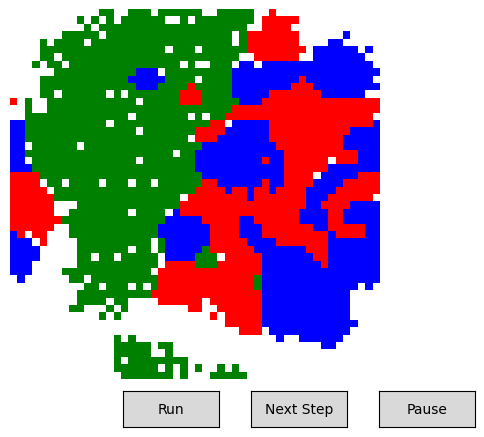

<Figure size 128x96 with 0 Axes>

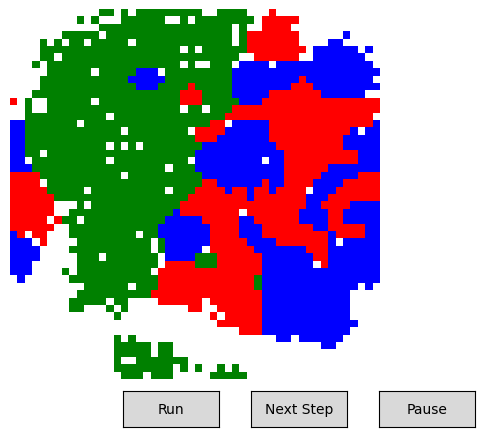

<Figure size 128x96 with 0 Axes>

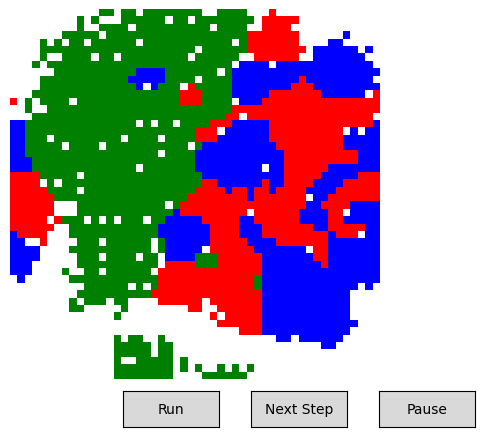

<Figure size 128x96 with 0 Axes>

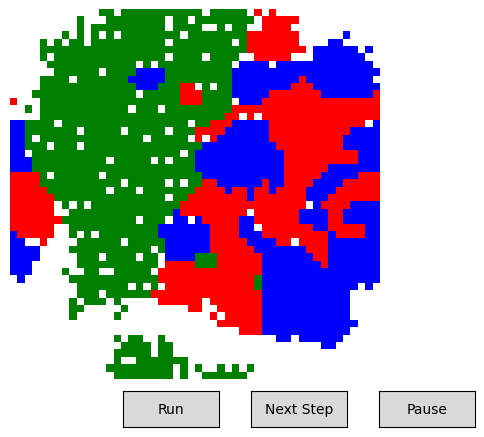

<Figure size 128x96 with 0 Axes>

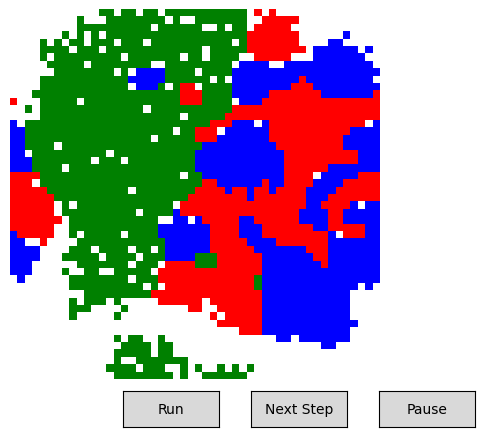

<Figure size 128x96 with 0 Axes>

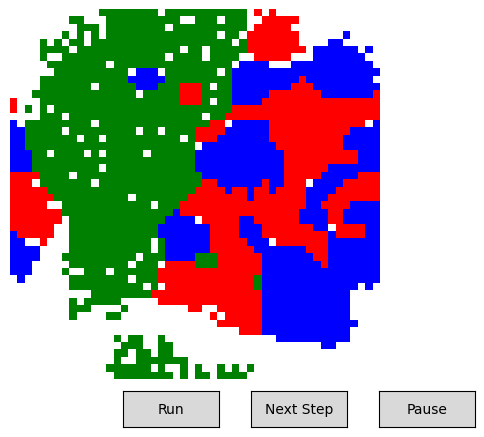

<Figure size 128x96 with 0 Axes>

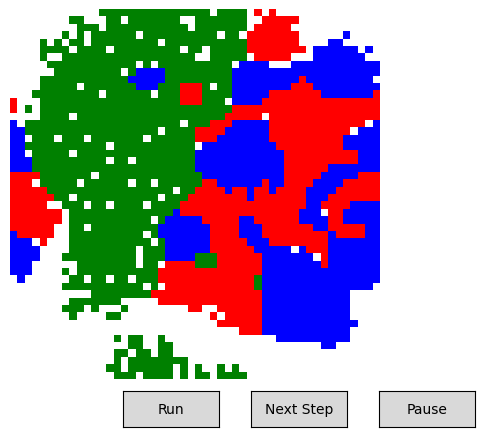

<Figure size 128x96 with 0 Axes>

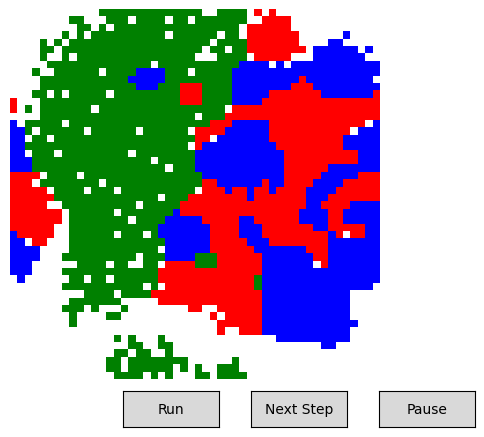

<Figure size 128x96 with 0 Axes>

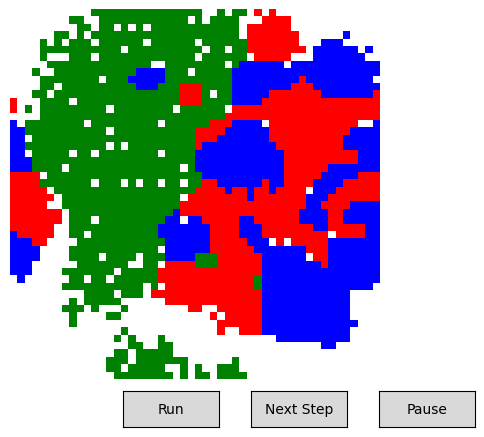

<Figure size 128x96 with 0 Axes>

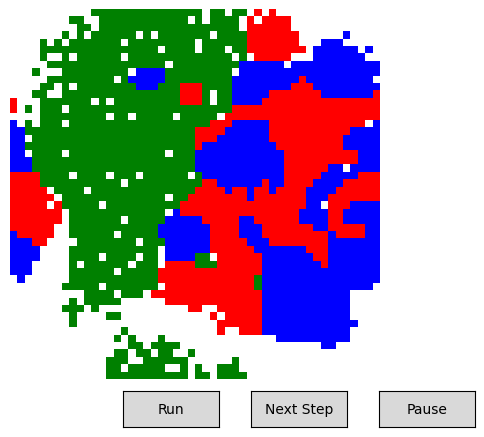

<Figure size 128x96 with 0 Axes>

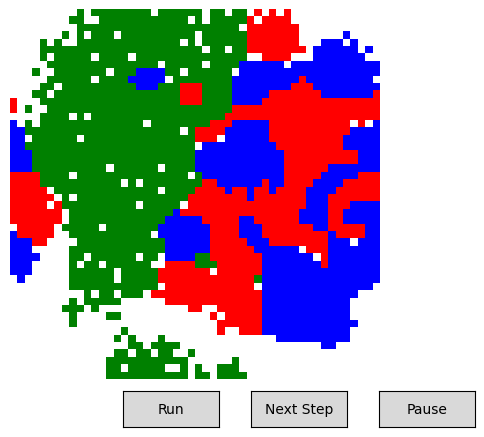

<Figure size 128x96 with 0 Axes>

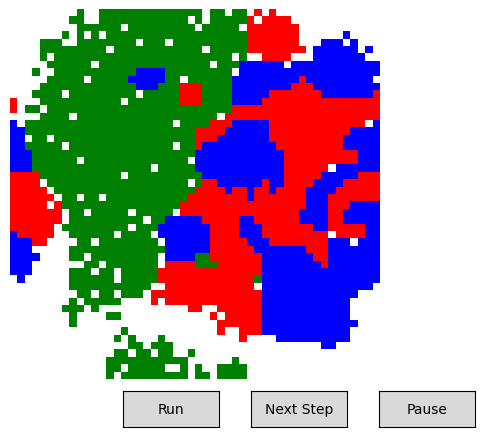

<Figure size 128x96 with 0 Axes>

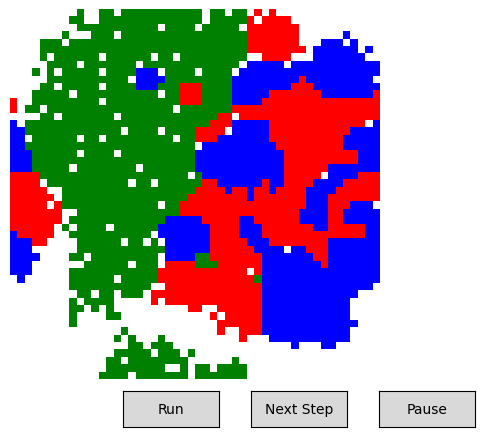

<Figure size 128x96 with 0 Axes>

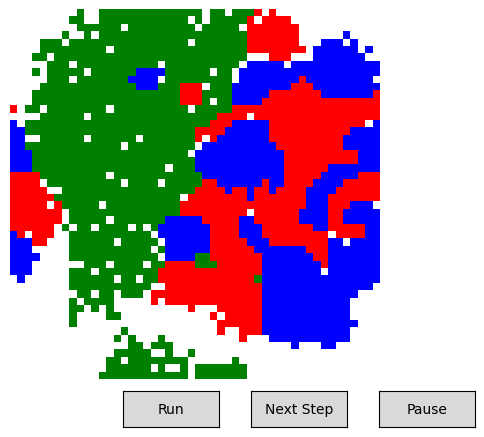

<Figure size 128x96 with 0 Axes>

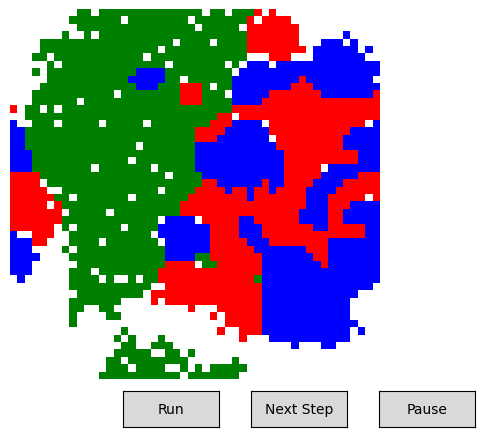

<Figure size 128x96 with 0 Axes>

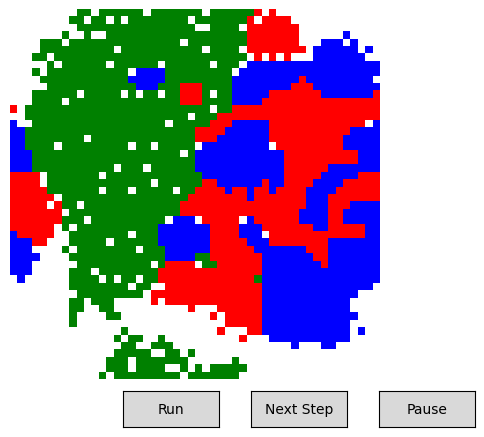

<Figure size 128x96 with 0 Axes>

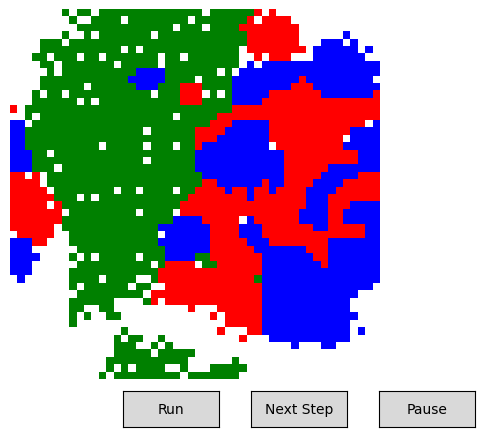

<Figure size 128x96 with 0 Axes>

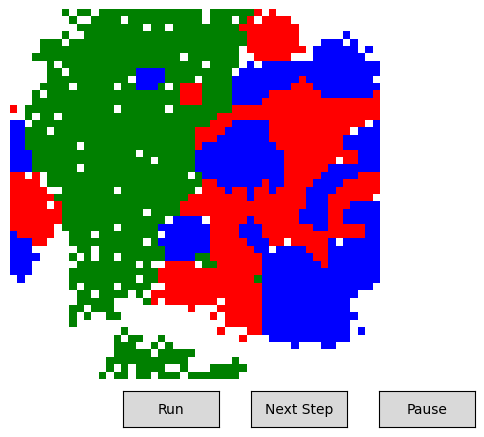

<Figure size 128x96 with 0 Axes>

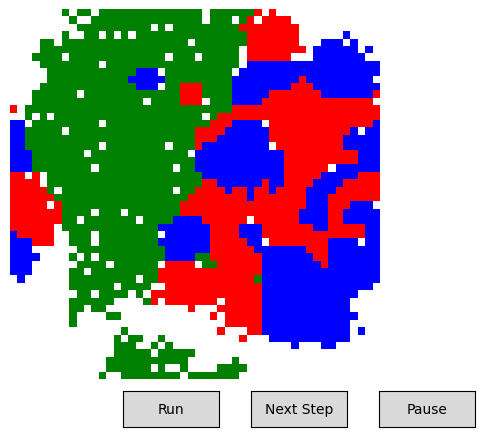

<Figure size 128x96 with 0 Axes>

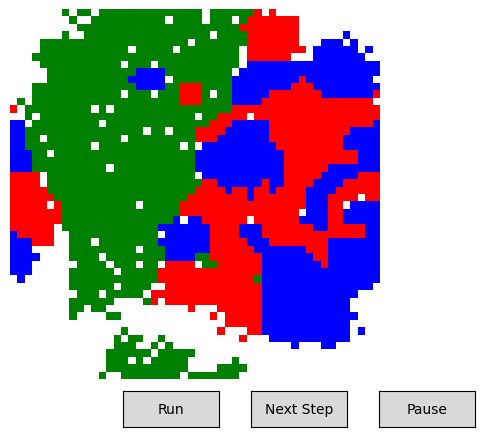

<Figure size 128x96 with 0 Axes>

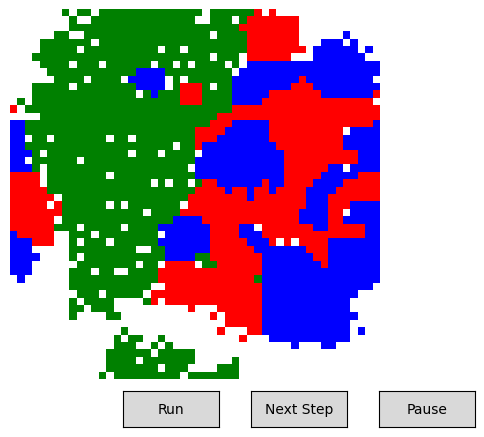

<Figure size 128x96 with 0 Axes>

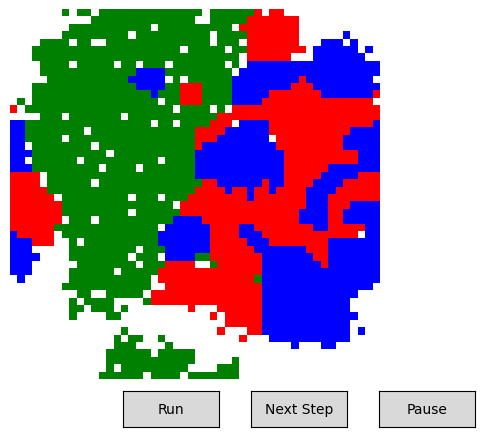

<Figure size 128x96 with 0 Axes>

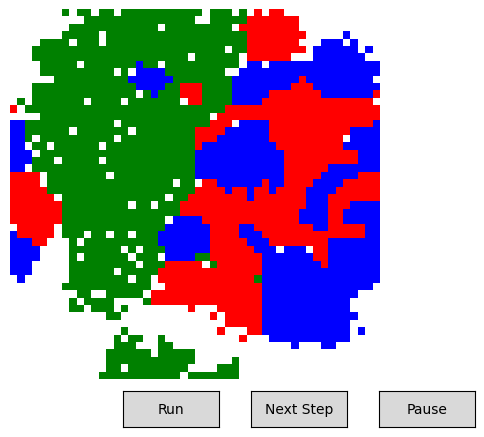

<Figure size 128x96 with 0 Axes>

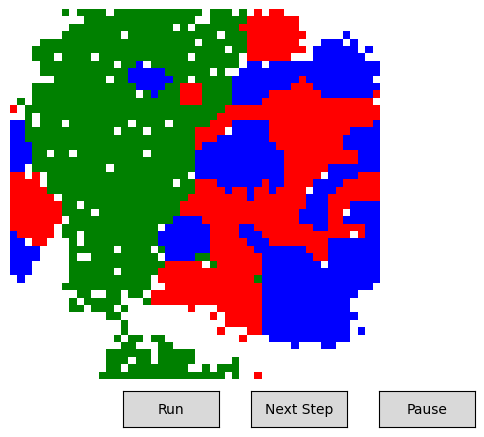

<Figure size 128x96 with 0 Axes>

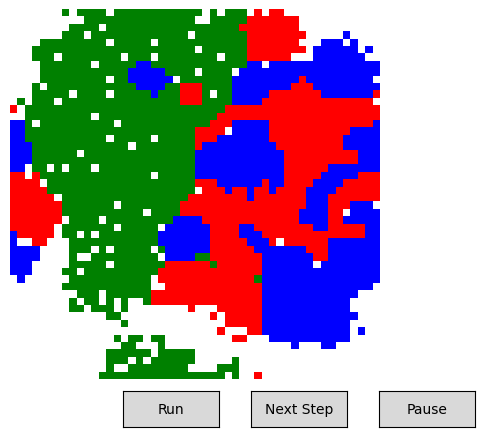

<Figure size 128x96 with 0 Axes>

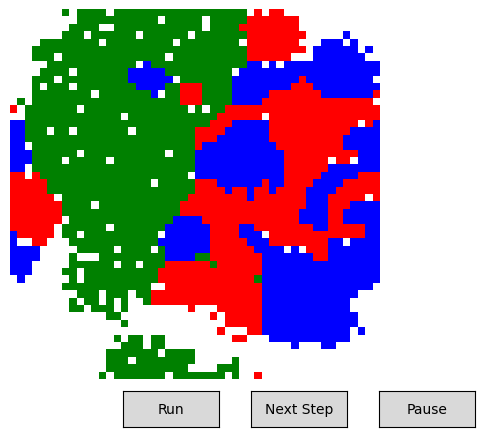

<Figure size 128x96 with 0 Axes>

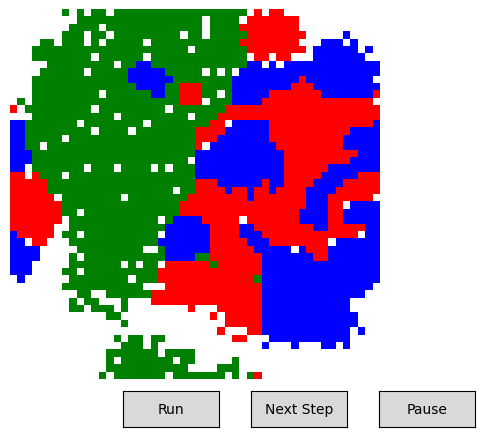

<Figure size 128x96 with 0 Axes>

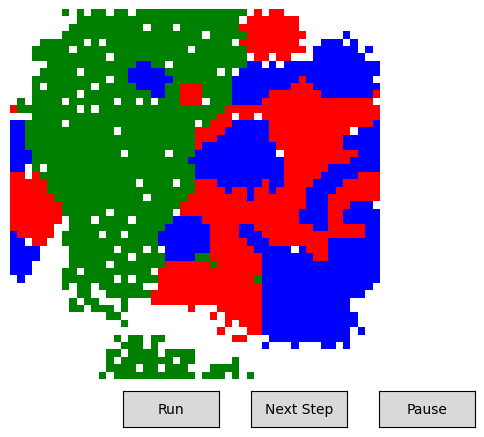

<Figure size 128x96 with 0 Axes>

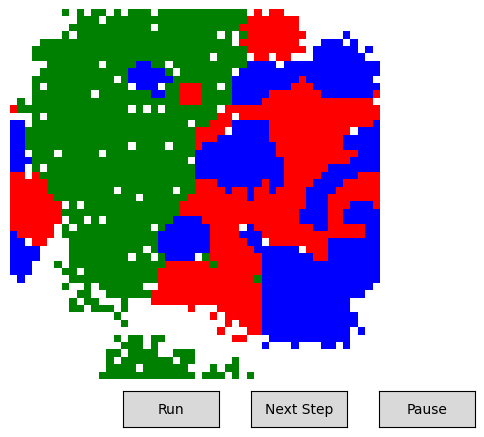

<Figure size 128x96 with 0 Axes>

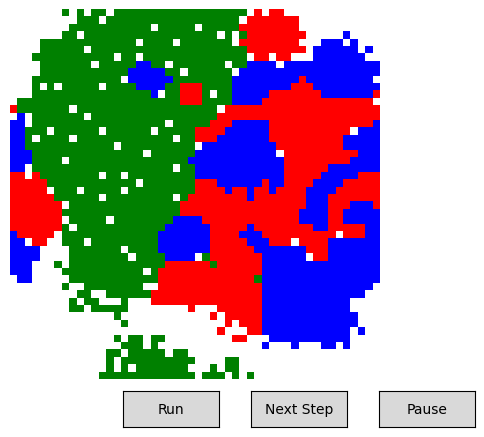

<Figure size 128x96 with 0 Axes>

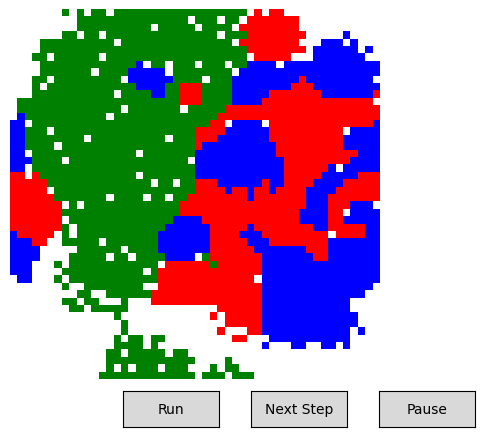

<Figure size 128x96 with 0 Axes>

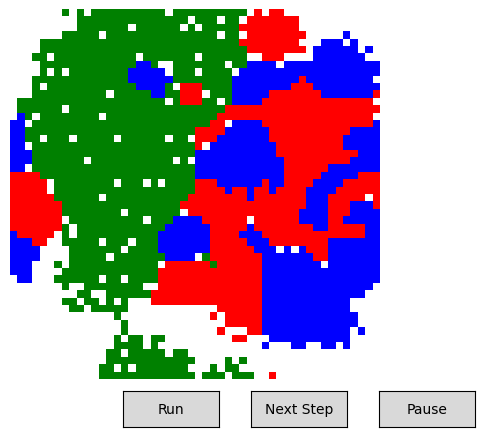

<Figure size 128x96 with 0 Axes>

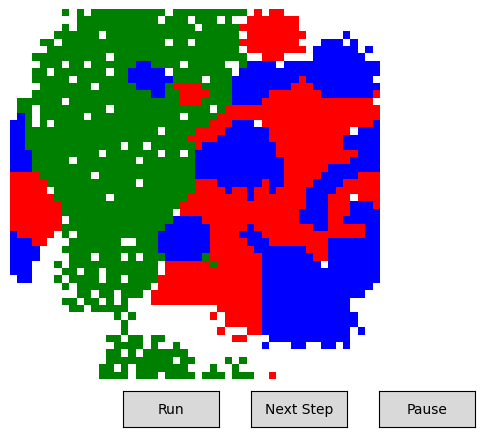

<Figure size 128x96 with 0 Axes>

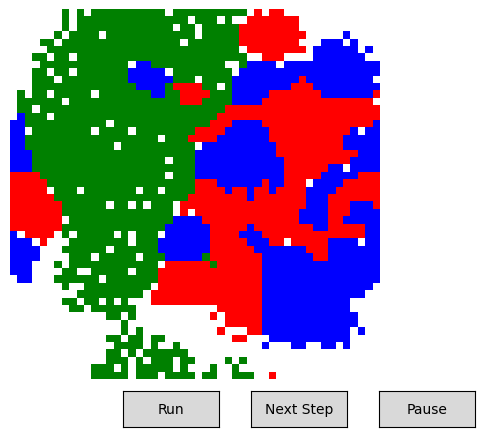

<Figure size 128x96 with 0 Axes>

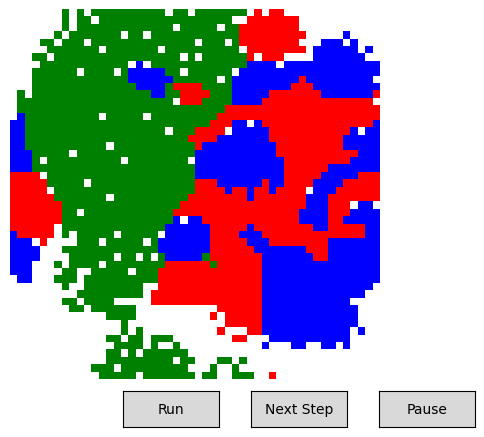

<Figure size 128x96 with 0 Axes>

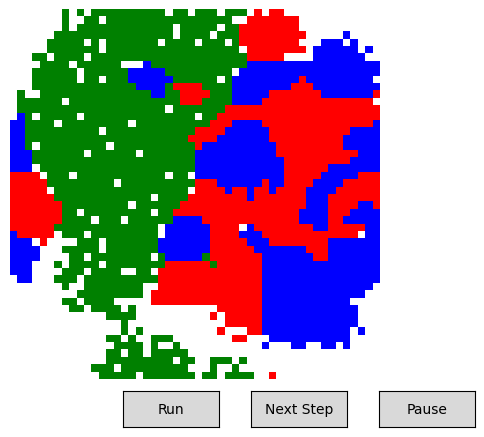

<Figure size 128x96 with 0 Axes>

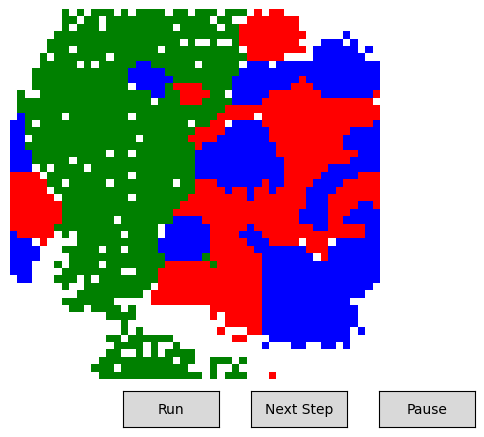

<Figure size 128x96 with 0 Axes>

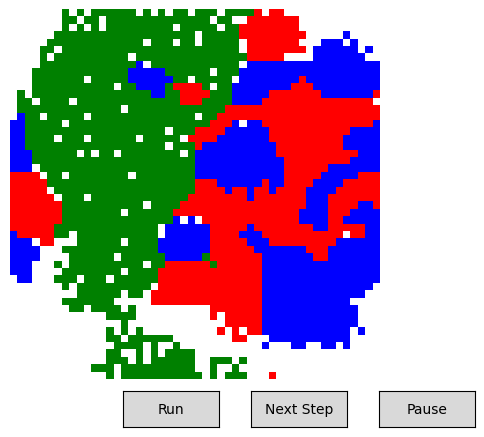

<Figure size 128x96 with 0 Axes>

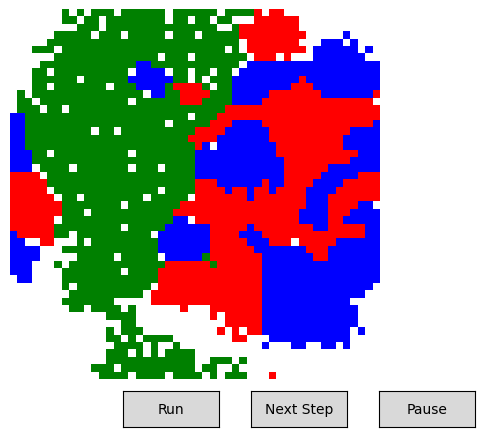

<Figure size 128x96 with 0 Axes>

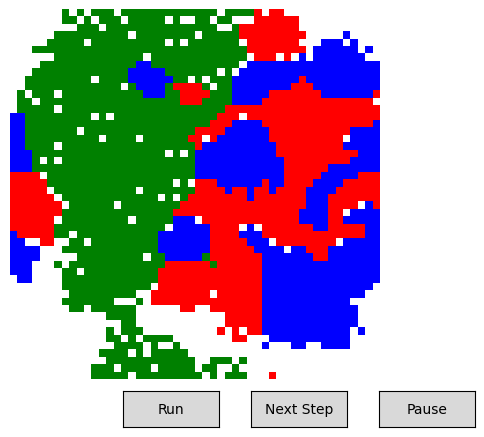

<Figure size 128x96 with 0 Axes>

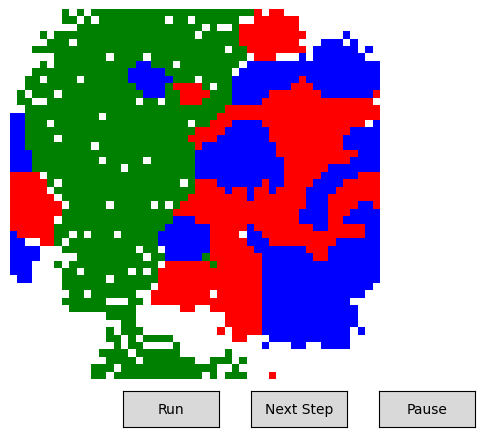

<Figure size 128x96 with 0 Axes>

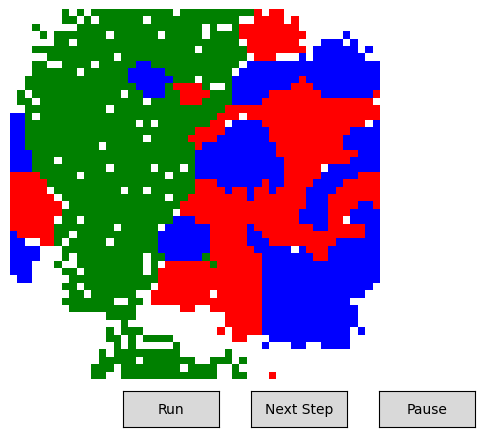

<Figure size 128x96 with 0 Axes>

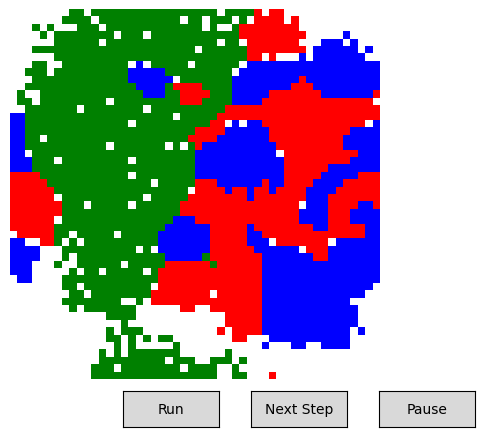

<Figure size 128x96 with 0 Axes>

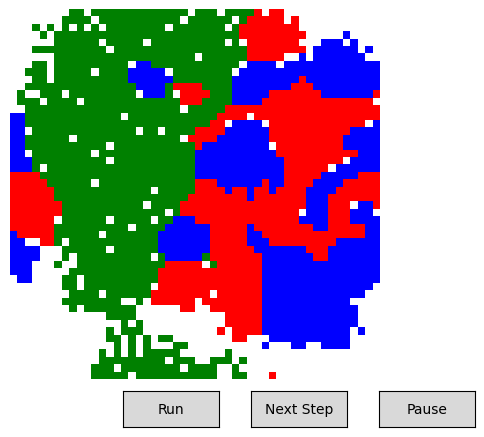

Test reward: -1.8410


In [74]:
env = SquareSimulation(
    nb_batch=1,
    rows=50,
    cols=50,
    populations=populations,
    device=device,
)
env.reset()

def test_policy(env, policy_net, nb_steps=500):
    env.reset()
    ep_reward = 0
    for t in range(nb_steps):
        
        if t % 5 == 0:
            plt.figure(dpi=20)
            grid_simulation.run_visual_simulation_grid(env)

            with torch.no_grad():
                observations, obs_indices = env.get_deep_observations(clever_pop_id)
            
            action = select_action(observations)

            with torch.no_grad():
                all_actions_grid = clever_single_action(env, action, obs_indices) 
                
                rewards, done, info = env.step(all_actions_grid, obs_indices)
                
            clever_pop_rewards = rewards
            clever_pop_rewards = clever_pop_rewards
            ep_reward += clever_pop_rewards.mean().item()
            
    return ep_reward

# Test the policy
test_reward = test_policy(env, policy_net)
print(f"Test reward: {test_reward:.4f}")